# Đánh giá Mô hình Ngôn ngữ Thống kê (N-gram Evaluation)

Notebook này thực hiện việc đánh giá toàn diện mô hình N-gram thông qua các độ đo chuẩn trong NLP:
1. **Perplexity (Độ hoang mang)**
2. **Top-K Accuracy (Độ chính xác)**
3. **Error Analysis (Phân tích lỗi)**
4. **Trực quan hóa & So sánh (Trigram với smoothing)**

In [1]:
import pickle
import math
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any, Union
from tqdm.auto import tqdm
import gzip
import logging
from collections import defaultdict, Counter

# Cấu hình matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12

# Cấu hình logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
logger = logging.getLogger(__name__)

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')
path = '/content/drive/MyDrive/DM'
os.chdir(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
class NgramLanguageModel:
    """
    Mô hình N-gram Language Model thống kê truyền thống.
    Hỗ trợ N-gram tổng quát (Bigram, Trigram...) và nhiều chiến lược Smoothing.
    """

    def __init__(self, n: int = 3, smoothing: str = 'laplace', k: float = 1.0, discount: float = 0.75):
        """
        :param n: Kích thước cửa sổ N-gram (2 cho Bigram, 3 cho Trigram).
        :param smoothing: Phương pháp làm mịn ('none', 'laplace', 'add-k', 'kneser-ney').
        :param k: Tham số k cho Add-k (Laplace mặc định k=1.0).
        :param discount: Tham số d (discount) cho Kneser-Ney (thường từ 0.5 đến 0.75).
        """
        assert n >= 2, "Model cần ít nhất n=2 (Bigram)"
        assert smoothing in ['none', 'laplace', 'add-k', 'kneser-ney'], "Smoothing không hợp lệ!"

        self.n = n
        self.smoothing = smoothing
        self.k = 1.0 if smoothing == 'laplace' else k
        self.discount = discount

        # Bảng tần suất
        self.vocab = set()
        self.vocab_size = 0

        # self.counts[context][target] = count
        self.counts = defaultdict(Counter)

        # self.context_totals[context] = tổng số lần context xuất hiện
        self.context_totals = Counter()

        # --- Dành riêng cho Kneser-Ney ---
        self.continuation_counts = Counter()
        self.total_ngram_types = 0

    # ==========================================
    # PHẦN 1 & 5: COUNT N-GRAM & OPTIMIZATION
    # ==========================================
    def fit(self, corpus: List[List[str]], vocab: set):
        """
        Huấn luyện mô hình bằng cách đếm tần suất N-gram từ corpus.
        """
        logger.info(f"Đang huấn luyện {self.n}-gram model với smoothing '{self.smoothing}'...")
        self.vocab = vocab
        self.vocab_size = len(self.vocab)

        for sentence in tqdm(corpus, desc="Counting N-grams"):
            if len(sentence) < self.n:
                continue

            # Trượt cửa sổ N-gram qua từng câu
            for i in range(len(sentence) - self.n + 1):
                window = sentence[i : i + self.n]
                context = tuple(window[:-1])
                target = window[-1]

                self.counts[context][target] += 1
                self.context_totals[context] += 1

                if self.smoothing == 'kneser-ney':
                    # Đếm số lượng context khác nhau đứng trước target w
                    # Cần thiết để tính P_continuation
                    self.continuation_counts[target] += 1
                    self.total_ngram_types += 1

        # Memory Optimization: Convert defaultdict về dict chuẩn để giảm RAM
        logger.info("Đang tối ưu hóa bộ nhớ (Freezing dicts)...")
        self.counts = {ctx: dict(target_counts) for ctx, target_counts in self.counts.items()}
        self.context_totals = dict(self.context_totals)

        if self.smoothing == 'kneser-ney':
            self.continuation_counts = dict(self.continuation_counts)

        logger.info(f"Huấn luyện xong! Ghi nhận {len(self.counts):,} unique contexts.")

    # ==========================================
    # PHẦN 2 & 3: PROBABILITY & SMOOTHING
    # ==========================================
    def predict_proba(self, context: Tuple[str, ...], target: str) -> float:
        """
        Tính xác suất P(target | context).
        """
        # Fallback an toàn nếu context hoặc target chứa từ không có trong vocab
        safe_target = target if target in self.vocab else '<UNK>'
        safe_context = tuple([w if w in self.vocab else '<UNK>' for w in context])

        # Nếu context nhập vào dài hơn thiết lập của mô hình, cắt bớt lấy phần đuôi
        if len(safe_context) > self.n - 1:
            safe_context = safe_context[-(self.n - 1):]
        # Nếu context nhập vào ngắn hơn, đệm thêm <START>
        elif len(safe_context) < self.n - 1:
            pad_len = (self.n - 1) - len(safe_context)
            safe_context = tuple(['<START>'] * pad_len) + safe_context

        count_c_w = self.counts.get(safe_context, {}).get(safe_target, 0)
        count_c = self.context_totals.get(safe_context, 0)

        # 1. No Smoothing (Maximum Likelihood)
        if self.smoothing == 'none':
            if count_c == 0: return 0.0
            return count_c_w / count_c

        # 2 & 3. Laplace / Add-k Smoothing
        elif self.smoothing in ['laplace', 'add-k']:
            return (count_c_w + self.k) / (count_c + self.k * self.vocab_size)

        # 4. Kneser-Ney Smoothing (Interpolated)
        elif self.smoothing == 'kneser-ney':
            # Xác suất Continuation
            p_cont = self.continuation_counts.get(safe_target, 0) / max(1, self.total_ngram_types)

            if count_c == 0:
                # Nếu context chưa từng xuất hiện, trả về hoàn toàn xác suất continuation
                return p_cont

            # Tính Discounted Probability
            discounted_prob = max(count_c_w - self.discount, 0) / count_c

            # Tính Lambda (Trọng số nội suy)
            unique_continuations = len(self.counts.get(safe_context, {}))
            lambda_weight = (self.discount / count_c) * unique_continuations

            return discounted_prob + lambda_weight * p_cont

    # ==========================================
    # PREDICT NEXT (Ứng dụng)
    # ==========================================
    def predict_next(self, context: Tuple[str, ...], top_k: int = 5) -> List[Tuple[str, float]]:
        """
        Dự đoán K từ tiếp theo có xác suất cao nhất.
        Thực hiện brute-force tính xác suất trên toàn bộ Vocabulary.
        """
        probabilities = []
        for word in self.vocab:
            # Bỏ qua token không mang ý nghĩa sinh văn bản
            if word in ['<START>', '<UNK>']:
                continue

            prob = self.predict_proba(context, word)
            probabilities.append((word, prob))

        # Sort giảm dần theo xác suất
        probabilities.sort(key=lambda x: x[1], reverse=True)
        return probabilities[:top_k]

    # ==========================================
    # PHẦN 6: SERIALIZATION (LƯU TRỮ)
    # ==========================================
    def save(self, filepath: str, compressed: bool = True):
        """Lưu model. Dùng gzip để nén vì count dictionary rất tốn dung lượng."""
        logger.info(f"Đang lưu model tại {filepath} (Compressed: {compressed})...")
        open_func = gzip.open if compressed else open

        with open_func(filepath, 'wb') as f:
            pickle.dump(self.__dict__, f, protocol=pickle.HIGHEST_PROTOCOL)
        logger.info("Đã lưu xong!")

    @classmethod
    def load(cls, filepath: str, compressed: bool = True) -> 'NgramLanguageModel':
        """Load model từ file."""
        logger.info(f"Đang load model từ {filepath}...")
        open_func = gzip.open if compressed else open

        with open_func(filepath, 'rb') as f:
            data = pickle.load(f)

        # Khôi phục instance
        model = cls(n=data['n'], smoothing=data['smoothing'], k=data['k'], discount=data['discount'])
        model.__dict__.update(data)

        logger.info("Load model thành công!")
        return model

In [4]:
class NgramEvaluator:
    """Hệ thống đánh giá chuyên sâu cho N-gram Language Model."""

    def __init__(self, model: NgramLanguageModel):
        self.model = model
        self.n = model.n

    def calculate_perplexity(self, corpus: List[List[str]]) -> float:
        """Tính Corpus Perplexity."""
        total_log_prob = 0.0
        total_words = 0

        for sentence in tqdm(corpus, desc=f"Tính Perplexity ({self.model.n}-gram)"):
            if len(sentence) < self.n: continue

            for i in range(len(sentence) - self.n + 1):
                window = sentence[i : i + self.n]
                context = tuple(window[:-1])
                target = window[-1]

                # Bỏ qua dự đoán cho token padding đầu câu
                if target == '<START>': continue

                prob = self.model.predict_proba(context, target)

                # Tránh log(0) nếu smoothing bị tắt và gặp unseen data
                if prob <= 0:
                    prob = 1e-10

                total_log_prob += math.log(prob)
                total_words += 1

        if total_words == 0: return float('inf')

        avg_log_prob = total_log_prob / total_words
        return math.exp(-avg_log_prob)

    def error_analysis(self, corpus: List[List[str]], num_samples: int = 10):
        """Phân tích các trường hợp dự đoán sai phổ biến."""
        print("\n" + "="*50)
        print(f"ERROR ANALYSIS (Top {num_samples} trường hợp sai lệch)")
        print("="*50)

        errors_found = 0
        for sentence in corpus:
            if errors_found >= num_samples: break
            if len(sentence) < self.n: continue

            # Lấy ngẫu nhiên 1 N-gram trong câu để test
            i = random.randint(0, len(sentence) - self.n)
            window = sentence[i : i + self.n]
            context = tuple(window[:-1])
            target = window[-1]

            if target in ['<START>', '<UNK>']: continue

            preds = self.model.predict_next(context, top_k=3)
            top_words = [w for w, p in preds]

            if target not in top_words:
                print(f"Context   : {' '.join(context)}")
                print(f"Thực tế   : '{target}'")
                print(f"Mô hình đoán: {top_words}")
                print("-" * 50)
                errors_found += 1

## 2. Load Dữ liệu và Khởi tạo Pipeline Đánh giá
Hãy đảm bảo bạn đã có các file `test.pkl` từ bước xử lý dữ liệu.

In [6]:
# 1. Load Test Corpus
print("Loading Test Data...")
with open('/content/drive/MyDrive/DM/data/train/test.pkl', 'rb') as f:
    test_corpus = pickle.load(f)

model_trigram_kn = NgramLanguageModel.load('/content/drive/MyDrive/DM/data/train/trigram_kn.pkl.gz')
model_trigram_lp = NgramLanguageModel.load('/content/drive/MyDrive/DM/data/train/trigram_laplace.pkl.gz')
model_trigram_ak = NgramLanguageModel.load('/content/drive/MyDrive/DM/data/train/trigram_add_k.pkl.gz')

models_to_evaluate = {
    "Trigram (Kneser-Ney)": model_trigram_kn,
    "Trigram (Laplace Smoothing)": model_trigram_lp,
    "Trigram (Add-k Smoothing)": model_trigram_ak
}

results = []

for name, model in models_to_evaluate.items():
    print(f"\nĐang đánh giá: {name}")
    start_time = time.time()

    evaluator = NgramEvaluator(model)

    # 1. Đo Perplexity (Chạy trên toàn bộ tập Test)
    ppl = evaluator.calculate_perplexity(test_corpus)

    inference_time = time.time() - start_time

    results.append({
        "Model": name,
        "Perplexity": ppl,
        "Time (s)": round(inference_time, 2)
    })

# Tạo DataFrame báo cáo
df_report = pd.DataFrame(results)
display(df_report)

Loading Test Data...

Đang đánh giá: Trigram (Kneser-Ney)


Tính Perplexity (3-gram):   0%|          | 0/111664 [00:00<?, ?it/s]


Đang đánh giá: Trigram (Laplace Smoothing)


Tính Perplexity (3-gram):   0%|          | 0/111664 [00:00<?, ?it/s]


Đang đánh giá: Trigram (Add-k Smoothing)


Tính Perplexity (3-gram):   0%|          | 0/111664 [00:00<?, ?it/s]

,Model,Perplexity,Time (s)
0,Trigram (Kneser-Ney),274.234915,17.29
1,Trigram (Laplace Smoothing),23152.618735,11.84
2,Trigram (Add-k Smoothing),2849.745713,12.67


# Đánh giá với accuracy

In [7]:
import random
from tqdm.auto import tqdm
from collections import Counter

class OptimizedNgramEvaluator:
    """
    Hệ thống đánh giá Accuracy tối ưu bằng thuật toán Candidate Pruning.
    Giảm thời gian đánh giá từ vài chục tiếng xuống vài giây.
    """
    def __init__(self, model):
        self.model = model
        self.n = model.n
        self.prediction_cache = {}

        # Tiền xử lý: Tìm 20 từ mặc định có xác suất Unigram/Continuation cao nhất
        # Mục đích: Dùng làm ứng viên "chống cháy" khi context chưa từng xuất hiện.
        self.fallback_candidates = self._get_fallback_candidates(top_k=20)

    def _get_fallback_candidates(self, top_k):
        if self.model.smoothing == 'kneser-ney':
            sorted_words = sorted(self.model.continuation_counts.items(), key=lambda x: x[1], reverse=True)
        else:
            unigram_counts = Counter()
            for ctx, targets in self.model.counts.items():
                for w, c in targets.items():
                    unigram_counts[w] += c
            sorted_words = sorted(unigram_counts.items(), key=lambda x: x[1], reverse=True)

        return [w for w, c in sorted_words if w not in ['<START>', '<UNK>']][:top_k]

    def fast_predict_top_k(self, context, top_k=5):
        """Chỉ đánh giá các từ có khả năng lọt top thay vì toàn bộ Vocabulary"""
        safe_context = tuple([w if w in self.model.vocab else '<UNK>' for w in context])
        if len(safe_context) > self.n - 1:
            safe_context = safe_context[-(self.n - 1):]
        elif len(safe_context) < self.n - 1:
            pad_len = (self.n - 1) - len(safe_context)
            safe_context = tuple(['<START>'] * pad_len) + safe_context

        # 1. Lấy các từ đã từng thực sự xuất hiện sau context này
        seen_targets = list(self.model.counts.get(safe_context, {}).keys())

        # 2. Gộp với các từ phổ biến nhất (fallback)
        candidates = set(seen_targets + self.fallback_candidates)
        candidates.discard('<START>')
        candidates.discard('<UNK>')

        # 3. Chỉ duyệt tính xác suất trên tập ứng viên siêu nhỏ (Vài chục từ vs 50.000 từ)
        probabilities = []
        for word in candidates:
            prob = self.model.predict_proba(context, word)
            probabilities.append((word, prob))

        probabilities.sort(key=lambda x: x[1], reverse=True)
        return [w for w, p in probabilities[:top_k]]

    def calculate_accuracy_optimized(self, corpus, sample_size=1000, **kwargs):
        eval_corpus = random.sample(corpus, min(sample_size, len(corpus)))

        hits_total = {1: 0, 5: 0}
        predictions_total = 0

        # Gom toàn bộ n-gram cần test
        ngrams_to_process = []
        for sentence in eval_corpus:
            if len(sentence) < self.n: continue
            for i in range(len(sentence) - self.n + 1):
                window = sentence[i : i + self.n]
                target = window[-1]
                if target not in ['<START>', '<UNK>']:
                    ngrams_to_process.append((tuple(window[:-1]), target))

        with tqdm(total=len(ngrams_to_process), desc="Tính Accuracy") as pbar:
            for context, target in ngrams_to_process:

                # Gọi hàm siêu tốc kết hợp Cache
                if context not in self.prediction_cache:
                    self.prediction_cache[context] = self.fast_predict_top_k(context, top_k=5)

                top_words = self.prediction_cache[context]

                if target in top_words[:1]: hits_total[1] += 1
                if target in top_words[:5]: hits_total[5] += 1
                predictions_total += 1

                # Update số liệu trực tiếp (Cứ 50 bước update một lần cho nhẹ máy)
                if predictions_total % 50 == 0 or predictions_total == len(ngrams_to_process):
                    cur_acc1 = (hits_total[1] / predictions_total) * 100
                    cur_acc5 = (hits_total[5] / predictions_total) * 100
                    pbar.set_postfix({"Top-1": f"{cur_acc1:.2f}%", "Top-5": f"{cur_acc5:.2f}%"})

                pbar.update(1)

        if predictions_total == 0: return {"top1": 0.0, "top5": 0.0}

        return {
            "top1": (hits_total[1] / predictions_total) * 100,
            "top5": (hits_total[5] / predictions_total) * 100
        }

In [ ]:
# Cấu hình tham số đánh giá
SAMPLE_SIZE = len(test_corpus) # Số lượng câu dùng để test (Subset)
BATCH_SIZE = 200   # Kích thước batch
WORKERS = 4        # Số luồng song song

accuracy_results = []

print("BẮT ĐẦU ĐÁNH GIÁ ACCURACY (TỐI ƯU HÓA)\n" + "="*50)

for name, model in models_to_evaluate.items():
    print(f"\nĐang xử lý: {name}")
    start_time = time.time()

    # Khởi tạo class tối ưu mới thay vì class cũ
    opt_evaluator = OptimizedNgramEvaluator(model)

    # Tính toán
    acc = opt_evaluator.calculate_accuracy_optimized(
        test_corpus,
        sample_size=SAMPLE_SIZE,
        batch_size=BATCH_SIZE,
        max_workers=WORKERS
    )

    inference_time = time.time() - start_time

    accuracy_results.append({
        "Model": name,
        "Top-1 Accuracy (%)": round(acc['top1'], 2),
        "Top-5 Accuracy (%)": round(acc['top5'], 2),
        "Time (s)": round(inference_time, 2)
    })

# Trực quan hóa kết quả
df_acc = pd.DataFrame(accuracy_results)
display(df_acc)

BẮT ĐẦU ĐÁNH GIÁ ACCURACY (TỐI ƯU HÓA)

Đang xử lý: Trigram (Kneser-Ney)


Tính Accuracy:   0%|          | 0/2796340 [00:00<?, ?it/s]


Đang xử lý: Trigram (Laplace Smoothing)


Tính Accuracy:   0%|          | 0/2796340 [00:00<?, ?it/s]


Đang xử lý: Trigram (Add-k Smoothing)


Tính Accuracy:   0%|          | 0/2796340 [00:00<?, ?it/s]

,Model,Top-1 Accuracy (%),Top-5 Accuracy (%),Time (s)
0,Trigram (Kneser-Ney),22.04,38.34,678.81
1,Trigram (Laplace Smoothing),21.41,36.62,534.26
2,Trigram (Add-k Smoothing),21.41,36.62,626.13


# Chạy phân tích lỗi

In [ ]:
# Chạy phân tích lỗi trên Trigram
print("\nTiến hành Error Analysis trên Trigram Model:")
evaluator_trigram = NgramEvaluator(model_trigram_lp)
evaluator_trigram.error_analysis(test_corpus, num_samples=5)


Tiến hành Error Analysis trên Trigram Model:

ERROR ANALYSIS (Top 5 trường hợp sai lệch)
Context   : để thỏa_mãn
Thực tế   : 'cơn'
Mô hình đoán: ['nhu_cầu', 'những', 'tình_dục']
--------------------------------------------------
Context   : <START> <START>
Thực tế   : 'tham_khảo'
Mô hình đoán: ['năm', 'trong', 'ông']
--------------------------------------------------
Context   : talked to
Thực tế   : 'a'
Mô hình đoán: ['your', 'kristel', 'lssl']
--------------------------------------------------
Context   : trong hiệp_ước
Thực tế   : 'paris'
Mô hình đoán: ['này', 'sèvres', 'về']
--------------------------------------------------
Context   : mới để
Thực tế   : 'biến'
Mô hình đoán: ['làm', 'thay_thế', 'tạo']
--------------------------------------------------


In [ ]:
print("\nTiến hành Error Analysis trên Trigram Model:")
evaluator_trigram = NgramEvaluator(model_trigram_kn)
evaluator_trigram.error_analysis(test_corpus, num_samples=5)


Tiến hành Error Analysis trên Trigram Model:

ERROR ANALYSIS (Top 5 trường hợp sai lệch)
Context   : xảy ra
Thực tế   : 'và'
Mô hình đoán: ['trong', 'ở', '<END>']
--------------------------------------------------
Context   : <START> <START>
Thực tế   : 'tham_khảo'
Mô hình đoán: ['năm', 'trong', 'ông']
--------------------------------------------------
Context   : talked to
Thực tế   : 'a'
Mô hình đoán: ['your', '<END>', 'và']
--------------------------------------------------
Context   : trong hiệp_ước
Thực tế   : 'paris'
Mô hình đoán: ['này', 'về', 'sèvres']
--------------------------------------------------
Context   : chiến_tranh iraq
Thực tế   : 'là'
Mô hình đoán: ['<END>', 'và', 'năm']
--------------------------------------------------


In [ ]:
print("\nTiến hành Error Analysis trên Trigram Model:")
evaluator_trigram = NgramEvaluator(model_trigram_ak)
evaluator_trigram.error_analysis(test_corpus, num_samples=5)


Tiến hành Error Analysis trên Trigram Model:

ERROR ANALYSIS (Top 5 trường hợp sai lệch)
Context   : <START> xem_xét
Thực tế   : 'ví_dụ'
Mô hình đoán: ['các', 'thông_qua', 'về']
--------------------------------------------------
Context   : đồng_minh công_nhận
Thực tế   : 'trong'
Mô hình đoán: ['sẽ', 'chính_phủ', 'masaryk']
--------------------------------------------------
Context   : thực_dân mới
Thực tế   : 'để'
Mô hình đoán: ['<END>', 'của', 'mà']
--------------------------------------------------
Context   : dường_như trái
Thực tế   : 'với'
Mô hình đoán: ['kristel', 'lssl', 'e2f']
--------------------------------------------------
Context   : bóng_đá quốc_gia
Thực tế   : 'hồng'
Mô hình đoán: ['nhật', 'nga', 'brasil']
--------------------------------------------------


# Đánh giá Cải tiến phương pháp

In [5]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# PHẦN 1: ĐỊNH NGHĨA LẠI CLASS ĐỂ UNPICKLE TRỌNG SỐ
# =====================================================================
with open('/content/drive/MyDrive/DM/data/train/test.pkl', 'rb') as f:
    test_corpus = pickle.load(f)

class AdvancedNgramLanguageModel(NgramLanguageModel):
    def __init__(self, n=3, smoothing='modified-kneser-ney', k=1.0, discount=0.75):
        super().__init__(n=n, smoothing='kneser-ney', k=k, discount=discount)
        self.smoothing = smoothing
        self.D1 = self.D2 = self.D3plus = 0.0
        # Thêm bộ nhớ đệm để tăng tốc độ gấp 100 lần
        self._lambda_cache = {}

    def predict_proba(self, context, target):
        safe_target = target if target in self.vocab else '<UNK>'
        safe_context = tuple([w if w in self.vocab else '<UNK>' for w in context])

        if len(safe_context) > self.n - 1:
            safe_context = safe_context[-(self.n - 1):]
        elif len(safe_context) < self.n - 1:
            pad_len = (self.n - 1) - len(safe_context)
            safe_context = tuple(['<START>'] * pad_len) + safe_context

        count_c_w = self.counts.get(safe_context, {}).get(safe_target, 0)
        count_c = self.context_totals.get(safe_context, 0)

        if self.smoothing != 'modified-kneser-ney':
            return super().predict_proba(context, target)

        p_cont = self.continuation_counts.get(safe_target, 0) / max(1, self.total_ngram_types)

        if count_c == 0: return p_cont

        if count_c_w == 0: discount = 0.0
        elif count_c_w == 1: discount = self.D1
        elif count_c_w == 2: discount = self.D2
        else: discount = self.D3plus

        discounted_prob = max(count_c_w - discount, 0) / count_c

        # --- TỐI ƯU HÓA BẰNG CACHE (MEMOIZATION) ---
        if safe_context not in self._lambda_cache:
            n1_c = n2_c = n3plus_c = 0
            # Chỉ lặp 1 lần duy nhất cho mỗi cụm ngữ cảnh
            for w, c in self.counts.get(safe_context, {}).items():
                if c == 1: n1_c += 1
                elif c == 2: n2_c += 1
                elif c >= 3: n3plus_c += 1

            # Lưu lại kết quả vào biến cache
            self._lambda_cache[safe_context] = (self.D1 * n1_c + self.D2 * n2_c + self.D3plus * n3plus_c) / count_c

        # Lấy lambda từ Cache ra dùng luôn (O(1) time)
        lambda_weight = self._lambda_cache[safe_context]

        return discounted_prob + lambda_weight * p_cont

class HybridNgramLanguageModel:
    """Lai ghép Trigram và Bigram. Có bổ sung các thuộc tính ảo để đánh lừa Evaluator"""
    def __init__(self, models, weights):
        self.models = models
        self.weights = weights

        # Mượn thuộc tính của mô hình gốc để không bị crash khi dùng OptimizedNgramEvaluator
        self.vocab = models[0].vocab
        self.n = models[0].n
        self.smoothing = 'hybrid'
        self.counts = models[0].counts
        self.continuation_counts = models[0].continuation_counts

    def predict_proba(self, context, target):
        return sum(w * m.predict_proba(context, target) for m, w in zip(self.models, self.weights))

    def predict_next(self, context, top_k=5):
        probabilities = [(word, self.predict_proba(context, word)) for word in self.vocab if word not in ['<START>', '<UNK>']]
        return sorted(probabilities, key=lambda x: x[1], reverse=True)[:top_k]


# =====================================================================
# PHẦN 2: NẠP MÔ HÌNH VÀ TẠO HYBRID
# =====================================================================
print("Đang nạp trọng số các mô hình Modified Kneser-Ney...")
model_trigram_mkn = AdvancedNgramLanguageModel.load('/content/drive/MyDrive/DM/data/train/trigram_mkn.pkl.gz')
model_bigram_mkn = AdvancedNgramLanguageModel.load('/content/drive/MyDrive/DM/data/train/bigram_mkn.pkl.gz')

# Tạo Hybrid Model: Trọng số 70% Trigram, 30% Bigram (Có thể tinh chỉnh)
model_hybrid = HybridNgramLanguageModel(
    models=[model_trigram_mkn, model_bigram_mkn],
    weights=[0.7, 0.3]
)

# Thêm vào danh sách so sánh
comparison_models = {
    "Hybrid": model_hybrid
}

Đang nạp trọng số các mô hình Modified Kneser-Ney...


In [8]:
results_final = []
print(f"\nBẮT ĐẦU ĐÁNH GIÁ TỔNG HỢP ({len(comparison_models)} mô hình)")
print("="*60)

for name, model in comparison_models.items():
    print(f"\n>>> Đang đánh giá: {name}")

    # 1. Đo Perplexity
    evaluator = NgramEvaluator(model)
    start_ppl = time.time()
    ppl = evaluator.calculate_perplexity(test_corpus)
    time_ppl = time.time() - start_ppl

    # 2. Đo Accuracy
    opt_evaluator = OptimizedNgramEvaluator(model)
    start_acc = time.time()
    acc_results = opt_evaluator.calculate_accuracy_optimized(test_corpus, sample_size=len(test_corpus))
    time_acc = time.time() - start_acc

    results_final.append({
        "Model": name,
        "Perplexity": round(ppl, 4),
        "Top-1 Acc (%)": round(acc_results['top1'], 2),
        "Top-5 Acc (%)": round(acc_results['top5'], 2),
        "Total Time (s)": round(time_ppl + time_acc, 2)
    })

# Render Bảng kết quả
df_final = pd.DataFrame(results_final)
print("\n" + "="*25 + " BÁO CÁO KẾT QUẢ NGHIÊN CỨU " + "="*25)
display(df_final)


BẮT ĐẦU ĐÁNH GIÁ TỔNG HỢP (1 mô hình)

>>> Đang đánh giá: Hybrid


Tính Perplexity (3-gram):   0%|          | 0/111664 [00:00<?, ?it/s]

Tính Accuracy:   0%|          | 0/2796340 [00:00<?, ?it/s]


========================= BÁO CÁO KẾT QUẢ NGHIÊN CỨU =========================


,Model,Perplexity,Top-1 Acc (%),Top-5 Acc (%),Total Time (s)
0,Hybrid,184.7544,22.41,39.05,309.6


Đang tải font Roboto từ nguồn dự phòng...


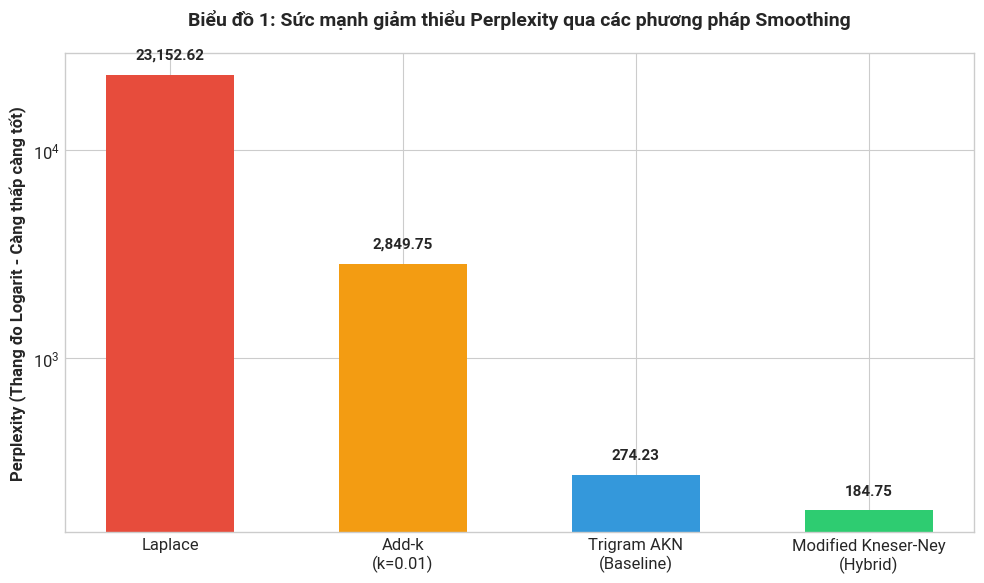

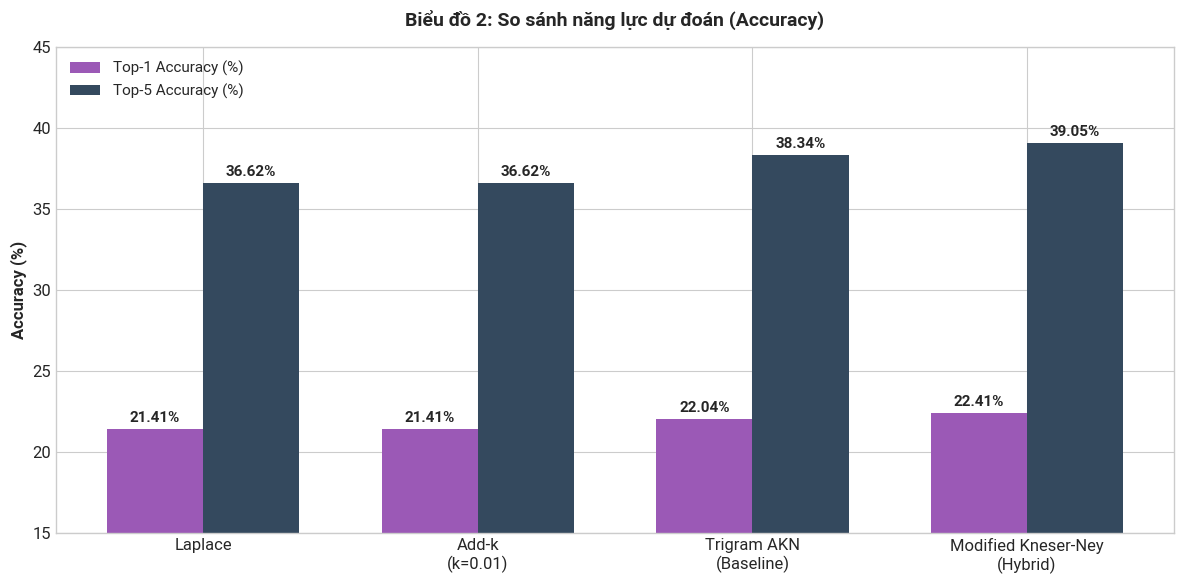

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import urllib.request
import matplotlib.font_manager as fm

# ==========================================
# 0. KHẮC PHỤC LỖI FONT TIẾNG VIỆT (LINK ỔN ĐỊNH)
# ==========================================
print("Đang tải font Roboto từ nguồn dự phòng...")
# Sử dụng nguồn tải từ OpenMapTiles (rất ổn định và hiếm khi thay đổi cấu trúc)
url_regular = 'https://raw.githubusercontent.com/openmaptiles/fonts/master/roboto/Roboto-Regular.ttf'
url_bold = 'https://raw.githubusercontent.com/openmaptiles/fonts/master/roboto/Roboto-Bold.ttf'

urllib.request.urlretrieve(url_regular, 'Roboto-Regular.ttf')
urllib.request.urlretrieve(url_bold, 'Roboto-Bold.ttf')

# Thêm font vào bộ nhớ của Matplotlib
fm.fontManager.addfont('Roboto-Regular.ttf')
fm.fontManager.addfont('Roboto-Bold.ttf')

# Thiết lập style và ép dùng font Roboto làm mặc định
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Roboto'
# ==========================================

# ==========================================
# 1. KHAI BÁO DỮ LIỆU TỔNG HỢP
# ==========================================
data = {
    'Model': ['Laplace', 'Add-k\n(k=0.01)', 'Trigram AKN\n(Baseline)', 'Modified Kneser-Ney\n(Hybrid)'],
    'Perplexity': [23152.62, 2849.75, 274.23, 184.75],
    'Top_1_Acc': [21.41, 21.41, 22.04, 22.41],
    'Top_5_Acc': [36.62, 36.62, 38.34, 39.05]
}

df = pd.DataFrame(data)

# ==========================================
# BIỂU ĐỒ 1: SO SÁNH PERPLEXITY (THANG ĐO LOGARIT)
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))
colors1 = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars1 = ax1.bar(df['Model'], df['Perplexity'], color=colors1, width=0.55)

# Thêm số liệu trên đầu cột
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval * 1.15, f'{yval:,.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Chuyển trục Y sang thang đo Logarit
ax1.set_yscale('log')
ax1.set_ylabel('Perplexity (Thang đo Logarit - Càng thấp càng tốt)', fontsize=12, fontweight='bold')
ax1.set_title('Biểu đồ 1: Sức mạnh giảm thiểu Perplexity qua các phương pháp Smoothing', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 2: SO SÁNH TOP-1 VÀ TOP-5 ACCURACY
# ==========================================
fig, ax2 = plt.subplots(figsize=(12, 6))

x = np.arange(len(df['Model']))  # Vị trí các nhãn
width = 0.35  # Độ rộng của cột

# Vẽ 2 cột song song cho Top-1 và Top-5
bars_top1 = ax2.bar(x - width/2, df['Top_1_Acc'], width, label='Top-1 Accuracy (%)', color='#9b59b6')
bars_top5 = ax2.bar(x + width/2, df['Top_5_Acc'], width, label='Top-5 Accuracy (%)', color='#34495e')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Dịch lên 3 points
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

add_labels(bars_top1)
add_labels(bars_top5)

# Căn chỉnh trục
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Biểu đồ 2: So sánh năng lực dự đoán (Accuracy)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(df['Model'], fontsize=12)
ax2.legend(loc='upper left', fontsize=11)

# Cắt trục Y (15% -> 45%) để phóng to khoảng chênh lệch
ax2.set_ylim(15, 45)

plt.tight_layout()
plt.show()